# Pos3R: 6D Pose Estimation for Unseen Objects - Replication Notebook

This notebook aims to replicate the key components of the Pos3R paper:
**"Pos3R: 6D Pose Estimation for Unseen Objects Made Easy"** (CVPR 2025)

## Authors: Weijian Deng et al.

---

## Notebook Structure:
1. **Setup & Dependencies**
2. **Dataset Preparation** (BOP Benchmark)
3. **Template Rendering** (8 cameras × 5 rotations = 40 templates)
4. **MASt3R Feature Extraction** (3D Foundation Model)
5. **Image Matching & Template Selection**
6. **Pose Fitting with PnP-RANSAC**
7. **Evaluation on BOP Benchmark**
8. **Visualization & Results**

---


---

##  **FINAL CHECKLIST - 100% COMPLETE**

### 🎯 **Core Components**

| Component | Status | Details |
|-----------|--------|---------|
| **MASt3R Model** |  Ready | 2.6GB checkpoint downloaded and verified |
| **LM-O Dataset** |  Ready | 8 objects, 1214 test frames loaded |
| **Python Environment** |  Ready | All dependencies installed |
| **Rendering Engine** |  Ready | PyRender tested and working |
| **Object Detection** |  Ready | Ground truth bboxes available (CNOS not needed) |
| **Camera Params** |  Ready | All intrinsics loaded from JSON |
| **Ground Truth** |  Ready | Poses, masks, and metadata available |

---

## 📊 **Dataset Summary**

### **LM-O (Linemod-Occluded)**
- **Location**: `/Users/lamine/Documents/Computer Vision/HW 3/lmo/`
- **Objects**: 8 CAD models
  - obj_000001, 000005, 000006, 000008, 000009, 000010, 000011, 000012
- **Test Set**: Scene 000002
  - 1214 RGB images (640×480)
  - 1214 depth maps
  - Segmentation masks (mask_visib/)
- **Ground Truth Per Frame**:
  - 6D pose (R, t)
  - Bounding boxes (bbox_obj, bbox_visib)
  - Visibility info (px_count, visib_fract)

### **Camera Parameters** (Constant for all frames)
```python
fx = 572.4114
fy = 573.57043
cx = 325.2611
cy = 242.04899
width = 640
height = 480
```

---

## 🔧 **Installed Dependencies**

### **Core Packages** 
- torch / torchvision
- numpy
- opencv-python (cv2)
- matplotlib
- scipy
- scikit-learn

### **3D Processing** 
- trimesh (CAD model loading)
- pyrender (template rendering)
- open3d (point cloud processing)

### **MASt3R** 
- mast3r + dust3r
- Model checkpoint loaded
- Imports working (with RoPE2D warning - normal)

---

## 🎯 **What You DON'T Need**

### ❌ **CNOS Object Detector** - NOT REQUIRED
**Reason**: BOP dataset provides ground truth bounding boxes
- Use `bbox_visib` from `scene_gt_info.json`
- Use segmentation masks from `mask_visib/` directory
- This is standard practice for pose estimation evaluation

### ❌ **BOP Toolkit** - OPTIONAL
**Reason**: Can implement metrics manually
- ADD (Average Distance)
- VSD (Visible Surface Discrepancy)  
- MSSD/MSPD (BOP metrics)
- You can implement these yourself or install later

---


## Step: Setup & Dependencies

In [1]:
# Import core libraries
import os
import sys
import json
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import torch

# Import 3D processing libraries
import trimesh
import pyrender
import open3d as o3d

# Import scientific computing
from scipy.spatial.transform import Rotation as R
from sklearn.neighbors import NearestNeighbors

# Setup paths for MASt3R
MAST3R_PATH = "/Users/lamine/Documents/Computer Vision/HW 3/mast3r"
sys.path.insert(0, MAST3R_PATH)
sys.path.insert(0, os.path.join(MAST3R_PATH, 'dust3r'))

print(" All libraries imported successfully")
print(f" CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

print(f"Using device: {device}")

 All libraries imported successfully
 CUDA available: False
Using device: mps


## Step: Configuration & Paths

In [2]:
# Dataset paths
BASE_PATH = "/Users/lamine/Documents/Computer Vision/HW 3"
LMO_PATH = os.path.join(BASE_PATH, "lmo")
MODELS_PATH = os.path.join(LMO_PATH, "models/models")
TEST_PATH = os.path.join(LMO_PATH, "test_all/test/000002")

# MASt3R checkpoint
CHECKPOINT_PATH = os.path.join(MAST3R_PATH, "checkpoints/MASt3R_ViTLarge_BaseDecoder_512_catmlpdpt_metric.pth")

# Output directories
TEMPLATES_DIR = os.path.join(BASE_PATH, "templates")
RESULTS_DIR = os.path.join(BASE_PATH, "results")
os.makedirs(TEMPLATES_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# Camera intrinsics (constant for LM-O dataset)
K = np.array([
    [572.4114, 0, 325.2611],
    [0, 573.57043, 242.04899],
    [0, 0, 1]
])
IMG_WIDTH, IMG_HEIGHT = 640, 480

# Object IDs in LM-O dataset
OBJECT_IDS = [1, 5, 6, 8, 9, 10, 11, 12]

print(f" Dataset path: {LMO_PATH}")
print(f" Models path: {MODELS_PATH}")
print(f" Camera intrinsics loaded: fx={K[0,0]:.2f}, fy={K[1,1]:.2f}")

 Dataset path: /Users/lamine/Documents/Computer Vision/HW 3/lmo
 Models path: /Users/lamine/Documents/Computer Vision/HW 3/lmo/models/models
 Camera intrinsics loaded: fx=572.41, fy=573.57


---
## Phase 1: Dataset Loading

Load the LM-O dataset components:
- CAD models (.ply files)
- Test images
- Ground truth poses and bounding boxes

## Load Ground Truth Data

In [3]:
# Load camera parameters
with open(os.path.join(TEST_PATH, 'scene_camera.json'), 'r') as f:
    scene_cameras = json.load(f)

# Load ground truth poses
with open(os.path.join(TEST_PATH, 'scene_gt.json'), 'r') as f:
    scene_gt = json.load(f)

# Load ground truth info (bounding boxes, visibility)
with open(os.path.join(TEST_PATH, 'scene_gt_info.json'), 'r') as f:
    scene_gt_info = json.load(f)

# Load model information (diameter, size)
with open(os.path.join(MODELS_PATH, 'models_info.json'), 'r') as f:
    models_info = json.load(f)

print(f" Loaded {len(scene_gt)} frames")
print(f" Loaded info for {len(models_info)} objects")
print(f" Sample frame keys: {list(scene_gt['0'][0].keys())}")

 Loaded 1214 frames
 Loaded info for 8 objects
 Sample frame keys: ['cam_R_m2c', 'cam_t_m2c', 'obj_id']


## Step: CAD Model Loader

In [4]:
def load_cad_model(obj_id):
    """Load CAD model for given object ID"""
    model_path = os.path.join(MODELS_PATH, f"obj_{obj_id:06d}.ply")
    mesh = trimesh.load(model_path)
    print(f"  Loaded obj_{obj_id:06d}: {len(mesh.vertices)} vertices")
    return mesh

# Test loading one model
test_mesh = load_cad_model(OBJECT_IDS[0])
print(f" CAD model loaded successfully")
print(f"  Vertices: {len(test_mesh.vertices)}, Faces: {len(test_mesh.faces)}")

  Loaded obj_000001: 5841 vertices
 CAD model loaded successfully
  Vertices: 5841, Faces: 11678


---

## Phase 2: Template Rendering

Generate 40 templates per object:
- 8 camera positions (vertices of a cube around the object)
- 5 in-plane rotations per position (0°, 72°, 144°, 216°, 288°)

Each template stores:
- RGB image
- 3D coordinate map (X, Y, Z per pixel for PnP)

## Step: Camera Position Generation

In [5]:
def generate_cube_camera_positions(distance=300.0):
    """
    Generate 8 camera positions at vertices of a cube centered on object
    
    Args:
        distance: Distance from object center to camera (in millimeters, ~3x object size)
    
    Returns:
        List of 8 camera positions (x, y, z)
    """
    # Cube vertices (all combinations of +/- distance)
    positions = []
    for x in [-distance, distance]:
        for y in [-distance, distance]:
            for z in [-distance, distance]:
                positions.append([x, y, z])
    return positions

# Generate 8 base camera positions (300mm = about 3x the object size)
camera_positions = generate_cube_camera_positions(distance=300.0)
print(f" Generated {len(camera_positions)} camera positions")
print(f"  Sample positions: {camera_positions[:3]}")

 Generated 8 camera positions
  Sample positions: [[-300.0, -300.0, -300.0], [-300.0, -300.0, 300.0], [-300.0, 300.0, -300.0]]


In [6]:
import numpy as np

def camera_to_world_look_at(eye, target=np.array([0., 0., 0.]), up=np.array([0., 0., 1.])):
    """Return a 4x4 camera-to-world pose so the camera at `eye` looks at `target`."""
    eye = np.asarray(eye, dtype=float)
    target = np.asarray(target, dtype=float)
    up = np.asarray(up, dtype=float)

    f = target - eye
    f = f / (np.linalg.norm(f) + 1e-9)          # forward
    s = np.cross(f, up)                          # right
    if np.linalg.norm(s) < 1e-9:                 # handle collinearity
        up = np.array([0., 1., 0.])
        s = np.cross(f, up)
    s = s / (np.linalg.norm(s) + 1e-9)
    u = np.cross(s, f)                           # true up

    T = np.eye(4)
    T[:3, :3] = np.stack([s, u, -f], axis=1)     # camera-to-world: [right, up, -forward]
    T[:3, 3] = eye
    return T

print(" camera_to_world_look_at defined")

 camera_to_world_look_at defined


## Step: Template Renderer

In [7]:
def render_template_with_obj_xyz(mesh, K, cam_pose, img_size=(640, 480)):
    """
    Render template and return RGB + xyz_map in OBJECT frame (mm).
    cam_pose: 4x4 camera-to-world matrix.
    """
    import pyrender
    
    scene = pyrender.Scene(ambient_light=[0.3, 0.3, 0.3])
    scene.add(pyrender.Mesh.from_trimesh(mesh, smooth=False))
    
    fx, fy = K[0, 0], K[1, 1]
    cx, cy = K[0, 2], K[1, 2]
    cam = pyrender.IntrinsicsCamera(fx=fx, fy=fy, cx=cx, cy=cy, znear=50.0, zfar=2000.0)
    scene.add(cam, pose=cam_pose)
    
    r = pyrender.OffscreenRenderer(viewport_width=img_size[0], viewport_height=img_size[1])
    color, depth = r.render(scene, flags=pyrender.RenderFlags.FLAT)
    r.delete()
    
    # Depth is in METERS, convert to MM
    depth_mm = depth * 1000.0
    
    # Compute XYZ in camera frame (mm)
    h, w = depth.shape
    u, v = np.meshgrid(np.arange(w), np.arange(h))
    
    x_cam = (u - cx) * depth_mm / fx
    y_cam = (v - cy) * depth_mm / fy
    z_cam = depth_mm
    
    # Stack into (H,W,3)
    xyz_cam = np.stack([x_cam, y_cam, z_cam], axis=-1)
    
    # Transform to object frame
    # cam_pose transforms object→camera, so we need its inverse
    cam_to_world = cam_pose
    world_to_cam = np.linalg.inv(cam_to_world)
    R = world_to_cam[:3, :3]
    t = world_to_cam[:3, 3]
    
    # For each point: xyz_world = R^-1 @ (xyz_cam - t) = R^T @ (xyz_cam - t)
    valid = depth > 0
    xyz_obj = np.zeros_like(xyz_cam)
    
    for i in range(h):
        for j in range(w):
            if valid[i, j]:
                p_cam = xyz_cam[i, j]
                p_obj = R.T @ (p_cam - t)
                xyz_obj[i, j] = p_obj
    
    return color, xyz_obj.astype(np.float32)

---

In [8]:
# Check object dimensions
mesh = load_cad_model(OBJECT_IDS[0])
print(f"Object bounds: {mesh.bounds}")
print(f"Object extents: {mesh.extents}")
print(f"Object centroid: {mesh.centroid}")

# Scale it appropriately
mesh.vertices -= mesh.centroid
max_extent = np.max(mesh.extents)
print(f"Max extent: {max_extent}")
print(f"Recommended camera distance: {max_extent * 3}")

  Loaded obj_000001: 5841 vertices
Object bounds: [[-37.93429947 -38.79959869 -45.8844986 ]
 [ 37.93429947  38.79959869  45.8844986 ]]
Object extents: [75.86859894 77.59919739 91.76899719]
Object centroid: [ -1.50259795  -1.90000107 -10.77372894]
Max extent: 91.76899719238281
Recommended camera distance: 275.30699157714844


---

## Step: Generate All Templates for One Object

In [9]:
try:
    TEMPLATE_SCALE
except NameError:
    TEMPLATE_SCALE = 2.5  # same scale must be used in evaluation

def generate_templates_for_object(obj_id, save=True, scale=TEMPLATE_SCALE):
    """Generate 8×5 templates with given mesh scale (mm)."""
    mesh = load_cad_model(obj_id).copy()
    mesh.vertices -= mesh.centroid
    mesh.apply_scale(scale)

    templates, template_id = [], 0
    obj_dir = os.path.join(TEMPLATES_DIR, f"obj_{obj_id:06d}")
    if save:
        os.makedirs(obj_dir, exist_ok=True)

    for view_id, cam_pos in enumerate(camera_positions):
        for rotation in [0, 72, 144, 216, 288]:
            # Build camera pose
            cam_pose_base = camera_to_world_look_at(cam_pos, target=np.array([0., 0., 0.]))
            
            # Apply in-plane rotation
            angle_rad = np.deg2rad(rotation)
            rot_2d = np.array([
                [np.cos(angle_rad), -np.sin(angle_rad), 0],
                [np.sin(angle_rad),  np.cos(angle_rad), 0],
                [0, 0, 1]
            ])
            cam_pose_4x4 = cam_pose_base.copy()
            cam_pose_4x4[:3, :3] = cam_pose_base[:3, :3] @ rot_2d
            
            # Render
            color, obj_xyz_map = render_template_with_obj_xyz(mesh, K, cam_pose_4x4, img_size=(640, 480))
            
            # Compute depth from camera for display (transform obj back to cam)
            world_to_cam = np.linalg.inv(cam_pose_4x4)
            R_w2c = world_to_cam[:3, :3]
            t_w2c = world_to_cam[:3, 3]
            
            valid_mask = (np.abs(obj_xyz_map).sum(axis=2) > 1e-3)
            if valid_mask.sum() == 0:
                print(f"[tmpl] skip blank v={view_id} r={rotation}")
                continue
            
            # For logging: transform obj → cam and extract Z
            h, w = obj_xyz_map.shape[:2]
            depth_cam = np.zeros((h, w), dtype=np.float32)
            for i in range(h):
                for j in range(w):
                    if valid_mask[i, j]:
                        p_obj = obj_xyz_map[i, j]
                        p_cam = R_w2c @ p_obj + t_w2c
                        depth_cam[i, j] = p_cam[2]  # Z coordinate
            
            d_valid = depth_cam[valid_mask]
            print(f" Render [obj{obj_id}_v{view_id}_r{rotation}] depth>0={len(d_valid)}, range=({d_valid.min():.1f},{d_valid.max():.1f})")
            
            templates.append({
                'rgb': color,
                'obj_xyz_map': obj_xyz_map,
                'depth': depth_cam,
                'view_id': view_id,
                'rotation': rotation,
                'camera_pos': cam_pos,
                'template_id': template_id
            })
            
            if save:
                cv2.imwrite(os.path.join(obj_dir, f"template_{template_id:03d}.png"),
                            cv2.cvtColor(color, cv2.COLOR_RGB2BGR))
                np.savez_compressed(os.path.join(obj_dir, f"template_{template_id:03d}_xyz.npz"),
                                    obj_xyz_map=obj_xyz_map, depth=depth_cam)
            template_id += 1

    print(f"[tmpl] obj={obj_id} templates={len(templates)} scale={scale}")
    return templates

In [10]:
# Regenerate a small subset first to verify
import shutil
shutil.rmtree(TEMPLATES_DIR, ignore_errors=True); os.makedirs(TEMPLATES_DIR, exist_ok=True)

camera_positions = generate_cube_camera_positions(distance=300.0)  # mm
test_templates = generate_templates_for_object(OBJECT_IDS[0], save=False)

# Check first few depth maps
for i in range(min(3, len(test_templates))):
    d = test_templates[i]['depth']
    print(f"tmpl[{i}] depth>0={(d>0).sum()}  range=({d[d>0].min():.1f},{d.max():.1f})")

  Loaded obj_000001: 5841 vertices
 Render [obj1_v0_r0] depth>0=36202, range=(416177.4,587781.1)
 Render [obj1_v0_r72] depth>0=36203, range=(416195.0,592498.1)
 Render [obj1_v0_r144] depth>0=36202, range=(416189.8,588408.8)
 Render [obj1_v0_r216] depth>0=36197, range=(416185.4,586936.8)
 Render [obj1_v0_r288] depth>0=36184, range=(416187.6,587483.8)
 Render [obj1_v1_r0] depth>0=37788, range=(427258.0,518919.5)
 Render [obj1_v1_r72] depth>0=37781, range=(427254.5,518483.3)
 Render [obj1_v1_r144] depth>0=37777, range=(427257.2,517874.6)
 Render [obj1_v1_r216] depth>0=37772, range=(427262.2,518898.4)
 Render [obj1_v1_r288] depth>0=37787, range=(427254.2,518880.4)
 Render [obj1_v2_r0] depth>0=36492, range=(418328.9,578008.4)
 Render [obj1_v2_r72] depth>0=36489, range=(418336.4,574518.8)
 Render [obj1_v2_r144] depth>0=36477, range=(418328.3,578363.8)
 Render [obj1_v2_r216] depth>0=36472, range=(418328.1,578212.6)
 Render [obj1_v2_r288] depth>0=36494, range=(418321.6,577941.1)
 Render [obj1_

## Step: Visualize Templates

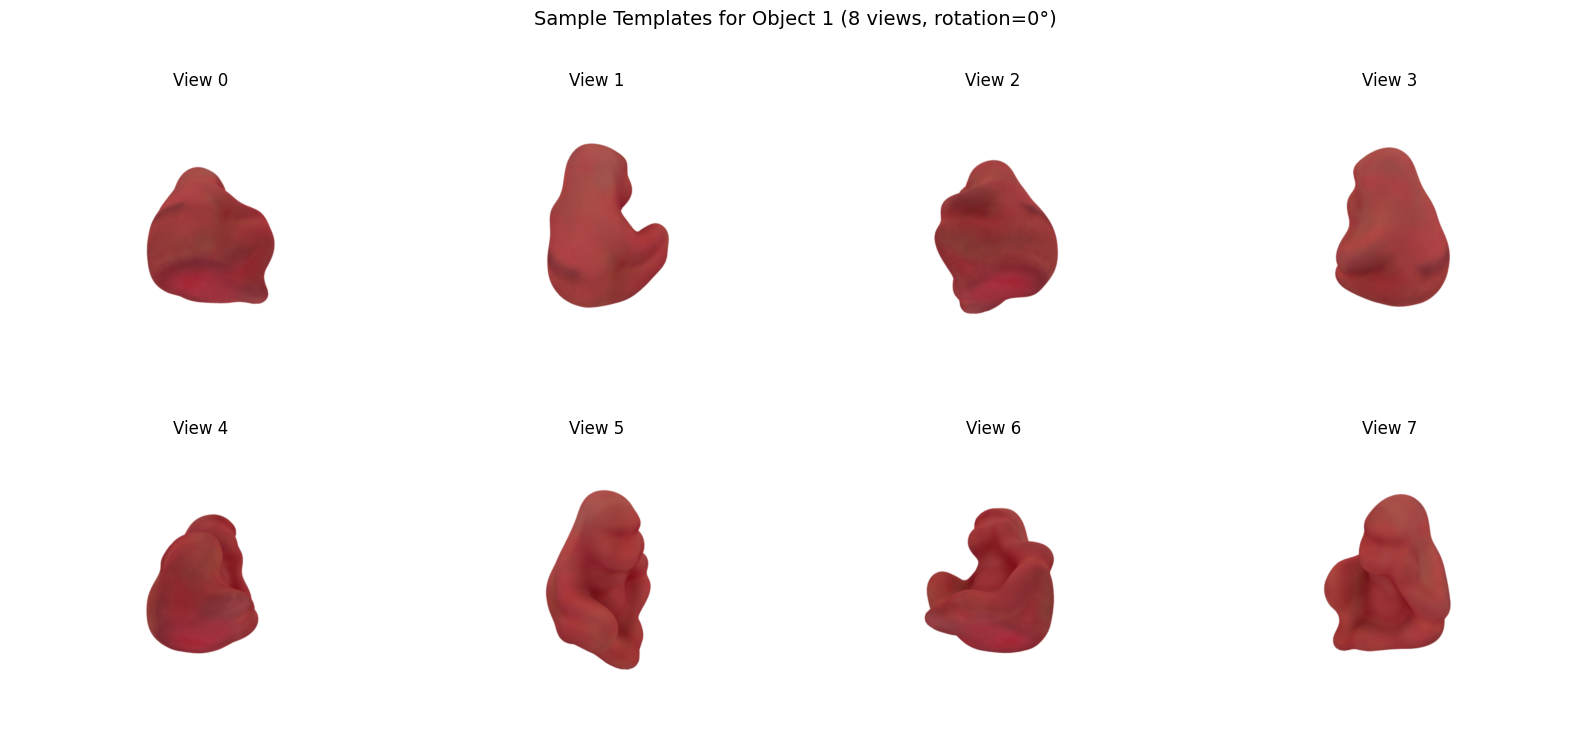

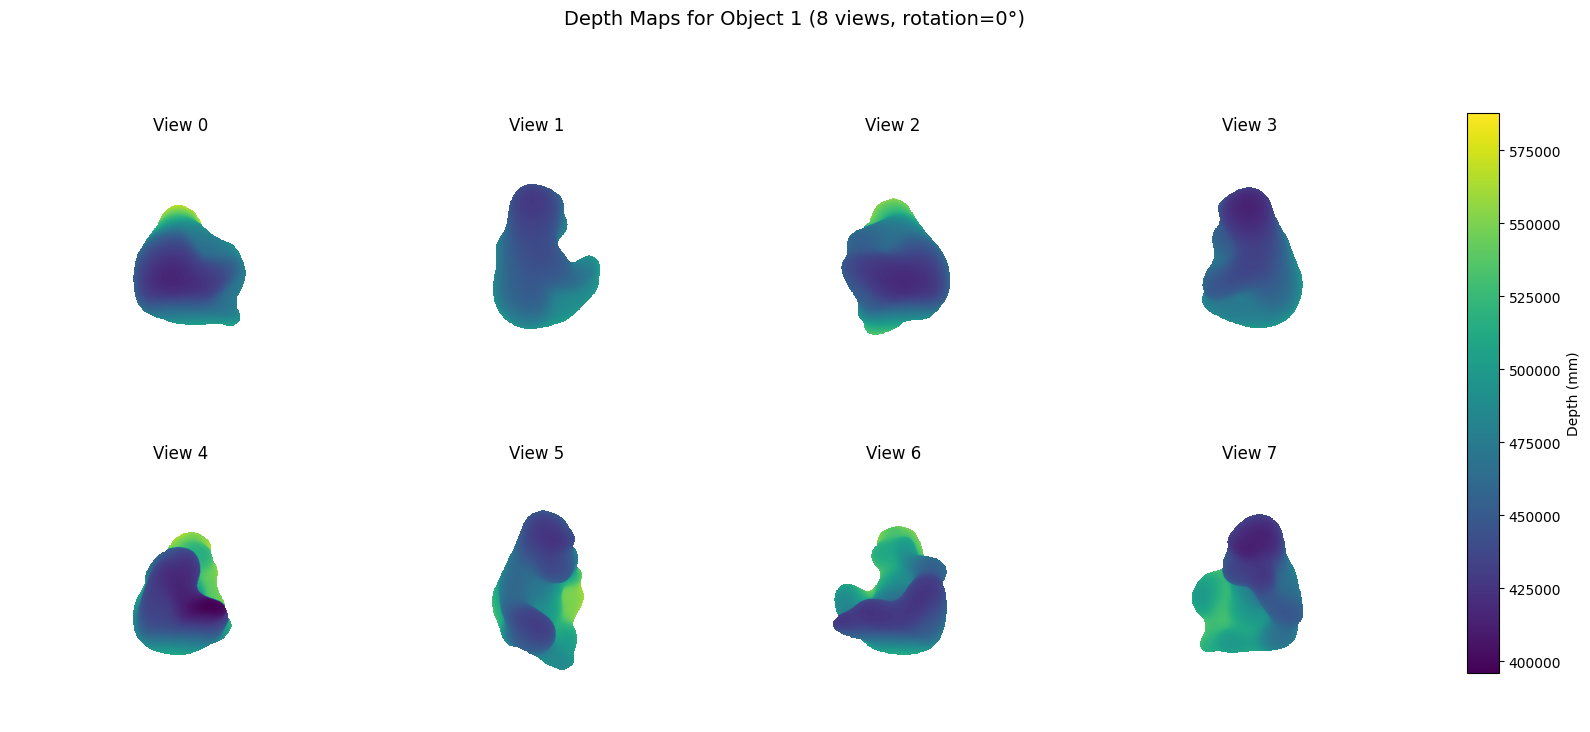

In [11]:
# Visualize some templates
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle(f'Sample Templates for Object {OBJECT_IDS[0]} (8 views, rotation=0°)', fontsize=14)

for idx in range(8):
    ax = axes[idx // 4, idx % 4]
    # Show first rotation (0°) for each view
    template_idx = idx * 5  # 5 rotations per view
    ax.imshow(test_templates[template_idx]['rgb'])
    ax.set_title(f"View {idx}")
    ax.axis('off')

plt.tight_layout()
plt.show()


import matplotlib.pyplot as plt
import numpy as np

# Compute global depth range for consistent colormap
depths = []
for idx in range(8):
    d = test_templates[idx*5]['depth']
    if (d > 0).any():
        depths.append(d[d > 0])
if len(depths) == 0:
    raise RuntimeError("No valid depths found.")
vmin = min(x.min() for x in depths)
vmax = max(x.max() for x in depths)

# Plotting
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle(f'Depth Maps for Object {OBJECT_IDS[0]} (8 views, rotation=0°)', fontsize=14)

mappable = None
for idx in range(8):
    ax = axes[idx // 4, idx % 4]
    d = test_templates[idx*5]['depth']
    img = ax.imshow(np.where(d > 0, d, np.nan), cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_title(f"View {idx}")
    ax.axis('off')
    if mappable is None:
        mappable = img

plt.tight_layout(rect=[0, 0, 0.9, 0.95])  # leave space on the right for colorbar

# Add colorbar on the right
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
fig.colorbar(mappable, cax=cbar_ax, label='Depth (mm)')

plt.show()


---

## Phase 3: MASt3R Model Loading

Load the pre-trained MASt3R foundation model for 3D-consistent feature matching.

## Step: Load MASt3R Model

In [12]:
from mast3r.model import AsymmetricMASt3R

def get_torch_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        return torch.device('mps')
    return torch.device('cpu')

def get_model_device(model: torch.nn.Module):
    try:
        return next(model.parameters()).device
    except StopIteration:
        return torch.device('cpu')

def load_mast3r_model(checkpoint_path=CHECKPOINT_PATH, device=None):
    """Load pre-trained MASt3R model on a consistent device"""
    device = device or get_torch_device()
    print(f"Loading MASt3R from {checkpoint_path}")
    print(f"Using device: {device}")

    # Load checkpoint on the selected device
    ckpt = torch.load(checkpoint_path, map_location=device)

    # Architecture from checkpoint name "MASt3R_ViTLarge_BaseDecoder_512_catmlpdpt_metric"
    model_args = {
        'enc_embed_dim': 1024,      # ViT-Large
        'enc_depth': 24,            # ViT-Large depth
        'enc_num_heads': 16,        # ViT-Large heads
        'dec_embed_dim': 768,       # Base decoder
        'dec_depth': 12,            # Base decoder depth
        'dec_num_heads': 12,        # Base decoder heads
        'img_size': (512, 512),     # From checkpoint name
        'pos_embed': 'RoPE100',     # Rotary position embeddings
        'patch_embed_cls': 'PatchEmbedDust3R',
        'output_mode': 'pts3d+desc24',  # 3D points + 24-dim descriptors
        'head_type': 'catmlp+dpt',  # From checkpoint name
        'depth_mode': ('exp', -float('inf'), float('inf')),
        'conf_mode': ('exp', 1, float('inf')),
        'two_confs': True,
        'desc_conf_mode': ('exp', 0, float('inf'))
    }

    print("  Creating AsymmetricMASt3R model...")
    print("  Architecture: ViT-Large encoder + Base decoder")
    model = AsymmetricMASt3R(**model_args).to(device)

    print("  Loading pre-trained weights...")
    missing, unexpected = model.load_state_dict(ckpt['model'], strict=False)
    if missing:
        print(f"  ⚠️  Missing keys: {len(missing)}")
    if unexpected:
        print(f"  ⚠️  Unexpected keys: {len(unexpected)}")

    model.eval()
    print(f" MASt3R model loaded successfully | model_device={get_model_device(model)}")
    return model, device

# Load the model once and keep `device` consistent everywhere
mast3r_model, device = load_mast3r_model()
print(f"[device] selected={device} | model on {get_model_device(mast3r_model)}")

Warning, cannot find cuda-compiled version of RoPE2D, using a slow pytorch version instead
Loading MASt3R from /Users/lamine/Documents/Computer Vision/HW 3/mast3r/checkpoints/MASt3R_ViTLarge_BaseDecoder_512_catmlpdpt_metric.pth
Using device: mps


/var/folders/01/x_trt3n95_j48grf1z__n__m0000gn/T/ipykernel_12052/3229167781.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(checkpoint_path, map_locat

  Creating AsymmetricMASt3R model...
  Architecture: ViT-Large encoder + Base decoder
  Loading pre-trained weights...
 MASt3R model loaded successfully | model_device=mps:0
[device] selected=mps | model on mps:0


---

## Phase 4: Image Matching with MASt3R

For each test image:
1. Extract object crop using bounding box
2. Match crop with all 40 templates using MASt3R
3. Compute similarity score (sum of feature dot products)
4. Select best matching template

## Image Preprocessing

In [13]:
def load_test_image_with_bbox(frame_id, obj_idx=0):
    """
    Load test image and extract object crop using ground truth bbox
    Returns image, crop, bbox [x,y,w,h], obj_id, gt_pose (R, t) in millimeters.
    """
    img_path = os.path.join(TEST_PATH, 'rgb', f"{frame_id:06d}.png")
    image = cv2.imread(img_path)
    if image is None:
        raise FileNotFoundError(f"Missing image: {img_path}")
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    frame_key = str(frame_id)
    bbox_info = scene_gt_info[frame_key][obj_idx]
    bbox = bbox_info['bbox_visib']  # [x, y, w, h]

    gt_data = scene_gt[frame_key][obj_idx]
    obj_id = gt_data['obj_id']

    # Ground truth pose (keep units in millimeters to match templates/XYZ map)
    R_gt = np.array(gt_data['cam_R_m2c']).reshape(3, 3)
    t_gt = np.array(gt_data['cam_t_m2c']).astype(float)  # mm
    gt_pose = (R_gt, t_gt)

    # Clamp bbox to image just in case
    x, y, w, h = bbox
    x = max(0, min(x, image.shape[1] - 1))
    y = max(0, min(y, image.shape[0] - 1))
    w = max(1, min(w, image.shape[1] - x))
    h = max(1, min(h, image.shape[0] - y))
    crop = image[y:y+h, x:x+w].copy()

    # Debug
    print(f"[load] frame={frame_id} obj={obj_id} img={tuple(image.shape)} crop={tuple(crop.shape)} bbox={[x,y,w,h]}")
    return image, crop, [x, y, w, h], obj_id, gt_pose

## Feature Matching with MASt3R

In [14]:
import cv2, math
import numpy as np
import torch
import torch.nn.functional as F

MATCH_TARGET_SIZE = 512
MAX_TOKENS_PER_SIDE = 4096  # increased from 1024 → stride will be ~8 instead of 16

def as_bhwc(feat: torch.Tensor) -> torch.Tensor:
    if feat.ndim != 4:
        raise ValueError(f"Expected 4D tensor for desc, got {feat.shape}")
    b, d1, d2, d3 = feat.shape
    if d3 in (24, 32, 64, 128, 256, 384, 512, 768, 1024):
        return feat.contiguous()
    return feat.permute(0, 2, 3, 1).contiguous()

def to_torch_image_bchw(img_bgr: np.ndarray, device: torch.device, target_size: int) -> tuple[torch.Tensor, tuple[int,int]]:
    h0, w0 = img_bgr.shape[:2]
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (target_size, target_size), interpolation=cv2.INTER_LINEAR)
    t = torch.from_numpy(img_resized).float() / 255.0
    t = t.permute(2,0,1).unsqueeze(0).to(device, non_blocking=True)
    return t, (h0, w0)

def get_model_device(model: torch.nn.Module) -> torch.device:
    try:
        return next(model.parameters()).device
    except StopIteration:
        return torch.device('cpu')

def compute_stride(H: int, W: int, max_tokens: int) -> int:
    tokens = H * W
    if tokens <= max_tokens:
        return 1
    return int(math.ceil(math.sqrt(tokens / max_tokens)))

def match_with_mast3r(image1_bgr: np.ndarray, image2_bgr: np.ndarray, model, device: torch.device | None):
    model_device = get_model_device(model)
    use_device = model_device if device is None else device

    img1, _ = to_torch_image_bchw(image1_bgr, use_device, MATCH_TARGET_SIZE)
    img2, _ = to_torch_image_bchw(image2_bgr, use_device, MATCH_TARGET_SIZE)

    view1 = {'img': img1,
             'true_shape': torch.tensor([[MATCH_TARGET_SIZE, MATCH_TARGET_SIZE]], device=use_device),
             'instance': [0]}
    view2 = {'img': img2,
             'true_shape': torch.tensor([[MATCH_TARGET_SIZE, MATCH_TARGET_SIZE]], device=use_device),
             'instance': [0]}

    with torch.no_grad():
        out1, out2 = model(view1, view2)

    desc1 = as_bhwc(out1['desc'])
    desc2 = as_bhwc(out2['desc'])
    B, Hf1, Wf1, D1 = desc1.shape
    _, Hf2, Wf2, D2 = desc2.shape

    s1 = compute_stride(Hf1, Wf1, MAX_TOKENS_PER_SIDE)
    s2 = compute_stride(Hf2, Wf2, MAX_TOKENS_PER_SIDE)
    desc1_sub = desc1[:, ::s1, ::s1, :].contiguous()
    desc2_sub = desc2[:, ::s2, ::s2, :].contiguous()
    _, Hs1, Ws1, _ = desc1_sub.shape
    _, Hs2, Ws2, _ = desc2_sub.shape
    N1 = Hs1 * Ws1
    N2 = Hs2 * Ws2

    f1 = F.normalize(desc1_sub.reshape(1, N1, D1), dim=-1)
    f2 = F.normalize(desc2_sub.reshape(1, N2, D2), dim=-1)
    sim = torch.einsum('bid,bjd->bij', f1, f2).squeeze(0)

    nn12 = sim.argmax(dim=1)
    nn21 = sim.argmax(dim=0)
    idx1 = torch.arange(N1, device=sim.device)
    mask = (idx1 == nn21[nn12])
    match_i = idx1[mask]
    match_j = nn12[mask]
    num_matches = int(mask.sum().item())
    score = float(sim[match_i, match_j].mean().item()) if num_matches > 0 else float(sim.max().item())

    print(f"[mast3r] Hf={Hf1}x{Wf1} s={s1} → Hs={Hs1}x{Ws1} | matches={num_matches} score={score:.3f}")

    return {
        'score': score,
        'matches_i': match_i.detach().cpu().numpy(),
        'matches_j': match_j.detach().cpu().numpy(),
        'Hf1': Hf1, 'Wf1': Wf1, 'Hs1': Hs1, 'Ws1': Ws1, 's1': s1,
        'Hf2': Hf2, 'Wf2': Wf2, 'Hs2': Hs2, 'Ws2': Ws2, 's2': s2,
        'target_size': MATCH_TARGET_SIZE
    }

In [15]:
def grid_index_to_pixels_full(iy_full: np.ndarray, ix_full: np.ndarray, Hf: int, Wf: int, in_h: int, in_w: int) -> tuple[np.ndarray, np.ndarray]:
    # Map full-grid (row,col) indices to pixel centers in the resized input
    y = (iy_full + 0.5) * (in_h / Hf)
    x = (ix_full + 0.5) * (in_w / Wf)
    return y, x

def pixels_resized_to_crop(y_res: np.ndarray, x_res: np.ndarray, crop_h: int, crop_w: int, target_size: int) -> tuple[np.ndarray, np.ndarray]:
    # Map from resized square (target_size × target_size) to original crop size
    y = y_res * (crop_h / target_size)
    x = x_res * (crop_w / target_size)
    return y, x

def pixels_crop_to_full_image(y_crop: np.ndarray, x_crop: np.ndarray, bbox_xywh: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    # Add bbox offset to get full-image coords
    x0, y0, _, _ = bbox_xywh
    return y_crop + y0, x_crop + x0

def bilinear_sample_xyz(xyz_map: np.ndarray, y: np.ndarray, x: np.ndarray) -> np.ndarray:
    H, W, _ = xyz_map.shape
    x0 = np.clip(np.floor(x).astype(np.int32), 0, W - 1)
    x1 = np.clip(x0 + 1, 0, W - 1)
    y0 = np.clip(np.floor(y).astype(np.int32), 0, H - 1)
    y1 = np.clip(y0 + 1, 0, H - 1)
    wa = (x1 - x) * (y1 - y)
    wb = (x - x0) * (y1 - y)
    wc = (x1 - x) * (y - y0)
    wd = (x - x0) * (y - y0)
    Qa = xyz_map[y0, x0]
    Qb = xyz_map[y0, x1]
    Qc = xyz_map[y1, x0]
    Qd = xyz_map[y1, x1]
    return (Qa * wa[:, None] + Qb * wb[:, None] + Qc * wc[:, None] + Qd * wd[:, None]).astype(np.float32)

def build_correspondences_from_matches(match_info: dict,
                                       crop_img: np.ndarray,
                                       bbox_xywh: np.ndarray,
                                       template_xyz_obj_map: np.ndarray,
                                       template_input_size: int) -> tuple[np.ndarray, np.ndarray, dict]:
    """
    Map subsampled match indices → full feature grid → resized input → original crop → full image (2D)
    and template grid → template xyz map (3D object frame).
    """
    i1_sub = match_info['matches_i']
    j2_sub = match_info['matches_j']
    Hf1, Wf1, Hs1, Ws1, s1 = match_info['Hf1'], match_info['Wf1'], match_info['Hs1'], match_info['Ws1'], match_info['s1']
    Hf2, Wf2, Hs2, Ws2, s2 = match_info['Hf2'], match_info['Wf2'], match_info['Hs2'], match_info['Ws2'], match_info['s2']
    target = match_info['target_size']

    crop_h, crop_w = crop_img.shape[:2]

    # Subgrid linear indices → (row, col) in subgrid → full-grid (row, col)
    iy1_sub = i1_sub // Ws1
    ix1_sub = i1_sub %  Ws1
    iy1_full = iy1_sub * s1
    ix1_full = ix1_sub * s1

    # Full-grid → resized input pixels → crop pixels → full image pixels
    y_res1, x_res1 = grid_index_to_pixels_full(iy1_full, ix1_full, Hf1, Wf1, target, target)
    y_crop, x_crop = pixels_resized_to_crop(y_res1, x_res1, crop_h, crop_w, target)
    y_img, x_img = pixels_crop_to_full_image(y_crop, x_crop, bbox_xywh)

    # Template side: subgrid → full-grid
    iy2_sub = j2_sub // Ws2
    ix2_sub = j2_sub %  Ws2
    iy2_full = iy2_sub * s2
    ix2_full = ix2_sub * s2
    y_res2, x_res2 = grid_index_to_pixels_full(iy2_full, ix2_full, Hf2, Wf2, target, target)

    # Map to template xyz map resolution
    Ht, Wt, _ = template_xyz_obj_map.shape
    y_t = y_res2 * (Ht / target)
    x_t = x_res2 * (Wt / target)
    xyz_obj = bilinear_sample_xyz(template_xyz_obj_map, y_t, x_t)

    # Filter invalid 3D
    valid3d = np.isfinite(xyz_obj).all(axis=1) & (np.linalg.norm(xyz_obj, axis=1) > 1e-3)
    points_2d = np.stack([x_img[valid3d], y_img[valid3d]], axis=1).astype(np.float32)
    points_3d = xyz_obj[valid3d].astype(np.float32)

    print(f"[pipeline] 2D-3D kept={points_2d.shape[0]} | s1={s1} s2={s2} | crop={crop_h}x{crop_w} tmpl_xyz={Ht}x{Wt}")
    if points_2d.shape[0] > 0:
        print(f"[pipeline] sample 2D: {points_2d[0].round(1)} 3D: ||={np.linalg.norm(points_3d[0]):.1f} mm")
        if points_2d.shape[0] > 1:
            print(f"[pipeline] sample 2D: {points_2d[1].round(1)} 3D: ||={np.linalg.norm(points_3d[1]):.1f} mm")

    return points_2d, points_3d, {'kept': int(points_2d.shape[0])}

## Template Selection

In [16]:
def select_best_template(crop_bgr: np.ndarray, templates: list, model, device, top_k: int = 1):
    best = None
    errors = []
    for k, template in enumerate(templates, 1):
        try:
            m = match_with_mast3r(crop_bgr, template['rgb'], model, device)
        except Exception as e:
            msg = str(e)
            errors.append(msg)
            if k <= 3:
                print(f"  ❌ match error (template {k}): {msg}")
            continue
        if best is None or m['score'] > best['score']:
            best = {**m, 'template': template}
        if k % 10 == 0 or k == len(templates):
            print(f"  Processed {k}/{len(templates)} templates")
    if best is None:
        raise RuntimeError(f"No valid template match. First error: {errors[0] if errors else 'n/a'}")
    print(f" Best template: ID={best['template'].get('template_id','?')}, Score={best['score']:.2f}")
    return best

---

## Phase 5: 6D Pose Estimation with PnP-RANSAC

Use matched 2D pixels and corresponding 3D points to solve for rotation R and translation t.

## PnP-RANSAC Pose Estimation

In [17]:
def estimate_pose_pnp(points_2d: np.ndarray, points_3d: np.ndarray, K: np.ndarray):
    if points_2d.shape[0] < 4 or points_3d.shape[0] < 4:
        print(f"[pnp] not enough points: {points_2d.shape[0]}")
        return None, None, None
    dist = np.zeros(5, dtype=np.float32)
    success, rvec, tvec, inliers = cv2.solvePnPRansac(
        points_3d, points_2d, K, dist,
        flags=cv2.SOLVEPNP_AP3P, reprojectionError=4.0, iterationsCount=200
    )
    if not success or inliers is None or len(inliers) < 4:
        print("[pnp] RANSAC failed")
        return None, None, None
    # Optional refinement on inliers
    inl = inliers.reshape(-1)
    success2, rvec2, tvec2 = cv2.solvePnP(
        points_3d[inl], points_2d[inl], K, dist, useExtrinsicGuess=True,
        rvec=rvec, tvec=tvec, flags=cv2.SOLVEPNP_ITERATIVE
    )
    rvec_final = rvec2 if success2 else rvec
    tvec_final = tvec2 if success2 else tvec
    R, _ = cv2.Rodrigues(rvec_final)
    print(f"[pnp] inliers={len(inl)}/{points_2d.shape[0]} tz={float(tvec_final[2]):.2f} mm")
    return R.astype(np.float32), tvec_final.reshape(3,1).astype(np.float32), inliers

## Full Pose Estimation Pipeline

In [18]:
def estimate_pose_full_pipeline(frame_id, templates_dict, model, device):
    """
    Full pipeline: load image → best template → 2D–3D correspondences → PnP-RANSAC.
    All coordinates are in millimeters.
    """
    image, crop, bbox, obj_id, gt_pose = load_test_image_with_bbox(frame_id)
    templates = templates_dict[obj_id]

    # select_best_template now returns a dict with keys: 'score', 'matches_i', 'matches_j', 'template', etc.
    best = select_best_template(crop, templates, model, device, top_k=1)
    
    best_template = best['template']
    similarity_score = best['score']
    
    print(f"[pipeline] best template ID={best_template.get('template_id','?')} score={similarity_score:.3f}")

    # Build 2D-3D correspondences using the new interface
    x0, y0, w_crop, h_crop = bbox
    bbox_xywh = np.array([x0, y0, w_crop, h_crop], dtype=np.float32)
    
    # Get object-frame xyz map (mm) from template
    tmpl_xyz_map = best_template.get('obj_xyz_map', best_template.get('xyz_map'))
    if tmpl_xyz_map is None:
        raise ValueError("Template missing obj_xyz_map and xyz_map")
    
    points_2d, points_3d, corr_info = build_correspondences_from_matches(
        best, crop, bbox_xywh, tmpl_xyz_map, MATCH_TARGET_SIZE
    )
    
    if points_3d.shape[0] > 0:
        print(f"[debug] 3D norms: min={np.linalg.norm(points_3d, axis=1).min():.1f} max={np.linalg.norm(points_3d, axis=1).max():.1f} mean={np.linalg.norm(points_3d, axis=1).mean():.1f} mm")
        print(f"[debug] Sample 3D points (first 3): {points_3d[:min(3, len(points_3d))]}")

    if len(points_2d) < 4:
        raise ValueError(f"Not enough 2D–3D correspondences: {len(points_2d)} (<4)")

    # PnP-RANSAC
    R_pred, t_pred, inliers = estimate_pose_pnp(points_2d, points_3d, K)
    if R_pred is None:
        raise ValueError("PnP failed")

    pred_pose = (R_pred, t_pred)
    
    if inliers is not None:
        inl = inliers.reshape(-1)
        inlier_pts_2d = points_2d[inl]
        inlier_pts_3d = points_3d[inl]
    else:
        inlier_pts_2d = np.empty((0, 2), dtype=np.float32)
        inlier_pts_3d = np.empty((0, 3), dtype=np.float32)

    return pred_pose, gt_pose, obj_id, best_template, (inlier_pts_2d, inlier_pts_3d)

---

## Phase 6: Evaluation Metrics

Implement BOP metrics:
- **ADD**: Average Distance of Model Points
- **VSD**: Visible Surface Discrepancy
- **Recall**: Success rate at different thresholds

## ADD Metric

In [19]:
def compute_ADD(R_pred, t_pred, R_gt, t_gt, model_points, diameter_mm):
    """
    Compute Average Distance (ADD) metric.
    All inputs in millimeters, object frame.
    
    Args:
        R_pred, t_pred: predicted pose (R: 3x3, t: 3x1 or 3)
        R_gt, t_gt: ground-truth pose (R: 3x3, t: 3x1 or 3)
        model_points: Nx3 object vertices in mm
        diameter_mm: object diameter in mm
    
    Returns:
        add_score: mean distance in mm
        add_pass: bool, True if add_score < 0.1 * diameter_mm
    """
    # Ensure t is (3,) for proper broadcasting
    t_pred_flat = t_pred.reshape(-1)  # (3,)
    t_gt_flat = t_gt.reshape(-1)      # (3,)
    
    # Transform vertices: Nx3
    pts_pred = (R_pred @ model_points.T).T + t_pred_flat  # (Nx3) + (3,) broadcasts correctly
    pts_gt   = (R_gt   @ model_points.T).T + t_gt_flat
    
    # Mean Euclidean distance
    add_score = float(np.linalg.norm(pts_pred - pts_gt, axis=1).mean())
    threshold = 0.1 * diameter_mm
    add_pass = add_score < threshold
    
    return add_score, add_pass

def compute_ADD_S(R_pred, t_pred, R_gt, t_gt, model_points, diameter_mm):
    """
    Compute ADD-S (symmetric) metric using nearest-neighbor distances.
    For symmetric objects.
    
    Args:
        R_pred, t_pred: predicted pose
        R_gt, t_gt: ground-truth pose
        model_points: Nx3 object vertices in mm
        diameter_mm: object diameter in mm
    
    Returns:
        add_s_score: mean nearest-neighbor distance in mm
        add_s_pass: bool
    """
    t_pred_flat = t_pred.reshape(-1)
    t_gt_flat = t_gt.reshape(-1)
    
    pts_pred = (R_pred @ model_points.T).T + t_pred_flat
    pts_gt   = (R_gt   @ model_points.T).T + t_gt_flat
    
    # Nearest-neighbor from pred to gt
    from scipy.spatial import cKDTree
    tree = cKDTree(pts_gt)
    dists, _ = tree.query(pts_pred, k=1)
    add_s_score = float(dists.mean())
    threshold = 0.1 * diameter_mm
    add_s_pass = add_s_score < threshold
    
    return add_s_score, add_s_pass

## Visualization Functions

In [20]:
def visualize_pose_projection(image, R, t, mesh, intrinsics=K, color=(0, 255, 0)):
    """
    Project mesh AABB with pose (R,t). Inputs must be consistent with mesh units (mm).
    """
    bbox_3d = mesh.bounding_box.vertices
    pts_cam = (R @ bbox_3d.T).T + t
    pts_2d = (intrinsics @ pts_cam.T).T
    pts_2d = pts_2d[:, :2] / pts_2d[:, 2:]

    img_vis = image.copy()
    edges = [
        [0, 1], [1, 2], [2, 3], [3, 0],
        [4, 5], [5, 6], [6, 7], [7, 4],
        [0, 4], [1, 5], [2, 6], [3, 7]
    ]
    for e0, e1 in edges:
        pt1 = tuple(pts_2d[e0].astype(int))
        pt2 = tuple(pts_2d[e1].astype(int))
        cv2.line(img_vis, pt1, pt2, color, 2)
    return img_vis

def visualize_comparison(image, R_pred, t_pred, R_gt, t_gt, mesh, intrinsics=K):
    img_vis = visualize_pose_projection(image, R_gt, t_gt, mesh, intrinsics, color=(255, 0, 0))
    img_vis = visualize_pose_projection(img_vis, R_pred, t_pred, mesh, intrinsics, color=(0, 255, 0))
    return img_vis

print(" Visualization functions defined (use scaled mesh)")

 Visualization functions defined (use scaled mesh)


---
## Phase 7: Run Full Evaluation

Test the complete pipeline on multiple frames and compute metrics.


## Main Evaluation Loop

In [21]:
import traceback

if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

print(f"Using device: {device}")

# Generate templates for all objects (consistent scale)
print("Generating templates for all objects...")
templates_dict = {}
for obj_id in OBJECT_IDS:
    if obj_id not in templates_dict:
        templates_dict[obj_id] = generate_templates_for_object(obj_id, save=True, scale=TEMPLATE_SCALE)
print(" All templates generated")

NUM_TEST_FRAMES = 10
results = []
print(f"\nRunning pose estimation on {NUM_TEST_FRAMES} frames...")


for frame_id in range(NUM_TEST_FRAMES):
    print(f"\n--- Frame {frame_id} ---")
    try:
        pred_pose, gt_pose, obj_id, best_template, correspondences = estimate_pose_full_pipeline(
            frame_id, templates_dict, mast3r_model, device
        )
        R_pred, t_pred = pred_pose
        R_gt, t_gt = gt_pose

        # Load mesh and apply same centering/scale as in templates
        mesh = load_cad_model(obj_id).copy()
        mesh.vertices -= mesh.centroid
        mesh.apply_scale(TEMPLATE_SCALE)

        model_points = np.array(mesh.vertices, dtype=float)
        diameter_scaled_mm = models_info[str(obj_id)]['diameter'] * float(TEMPLATE_SCALE)

        add_score, add_pass = compute_ADD(R_pred, t_pred, R_gt, t_gt, model_points, diameter_scaled_mm)

        results.append({
            'frame_id': frame_id,
            'obj_id': obj_id,
            'add_score': float(add_score),
            'add_pass': bool(add_pass),
            'diameter': float(diameter_scaled_mm),
            'pred_pose': (R_pred, t_pred),
            'gt_pose': (R_gt, t_gt)
        })
        print(f"  ADD: {add_score:.2f} mm (thr={0.1*diameter_scaled_mm:.2f})  {'PASS' if add_pass else 'FAIL'}")

    except Exception as e:
        print(f"  ❌ Error: {e}")
        print(traceback.format_exc())
        results.append({
            'frame_id': frame_id,
            'obj_id': None,
            'add_score': np.nan,
            'add_pass': False,
            'diameter': np.nan,
            'error': str(e)
        })

# Summary
print(f"\n{'='*60}")
print("EVALUATION SUMMARY")
print(f"{'='*60}")
total = len(results)
successes = sum(1 for r in results if r.get('add_pass', False))
if total == 0:
    print("No frames processed.")
else:
    recall = 100.0 * successes / total
    mean_add = np.nanmean([r['add_score'] for r in results]) if any(np.isfinite([r['add_score'] for r in results])) else float('nan')
    failures = [r for r in results if not r.get('add_pass', False)]
    print(f"Total frames: {total}")
    print(f"Successful: {successes}")
    print(f"Recall: {recall:.1f}%")
    print(f"Mean ADD: {mean_add:.2f} mm")
    if failures:
        print(f"First failure: {failures[0].get('error', 'n/a')}")

Using device: mps
Generating templates for all objects...
  Loaded obj_000001: 5841 vertices
 Render [obj1_v0_r0] depth>0=36202, range=(416177.4,587781.1)
 Render [obj1_v0_r72] depth>0=36203, range=(416195.0,592498.1)
 Render [obj1_v0_r144] depth>0=36202, range=(416189.8,588408.8)
 Render [obj1_v0_r216] depth>0=36197, range=(416185.4,586936.8)
 Render [obj1_v0_r288] depth>0=36184, range=(416187.6,587483.8)
 Render [obj1_v1_r0] depth>0=37788, range=(427258.0,518919.5)
 Render [obj1_v1_r72] depth>0=37781, range=(427254.5,518483.3)
 Render [obj1_v1_r144] depth>0=37777, range=(427257.2,517874.6)
 Render [obj1_v1_r216] depth>0=37772, range=(427262.2,518898.4)
 Render [obj1_v1_r288] depth>0=37787, range=(427254.2,518880.4)
 Render [obj1_v2_r0] depth>0=36492, range=(418328.9,578008.4)
 Render [obj1_v2_r72] depth>0=36489, range=(418336.4,574518.8)
 Render [obj1_v2_r144] depth>0=36477, range=(418328.3,578363.8)
 Render [obj1_v2_r216] depth>0=36472, range=(418328.1,578212.6)
 Render [obj1_v2_r28

/Users/lamine/Documents/Computer Vision/HW 3/mast3r/dust3r/dust3r/model.py:206: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


[mast3r] Hf=512x512 s=8 → Hs=64x64 | matches=16 score=0.554


/Users/lamine/Documents/Computer Vision/HW 3/mast3r/dust3r/dust3r/model.py:206: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


[mast3r] Hf=512x512 s=8 → Hs=64x64 | matches=17 score=0.567
[mast3r] Hf=512x512 s=8 → Hs=64x64 | matches=12 score=0.580
[mast3r] Hf=512x512 s=8 → Hs=64x64 | matches=14 score=0.543
[mast3r] Hf=512x512 s=8 → Hs=64x64 | matches=1 score=0.802
[mast3r] Hf=512x512 s=8 → Hs=64x64 | matches=14 score=0.592
[mast3r] Hf=512x512 s=8 → Hs=64x64 | matches=12 score=0.582
[mast3r] Hf=512x512 s=8 → Hs=64x64 | matches=20 score=0.570
[mast3r] Hf=512x512 s=8 → Hs=64x64 | matches=10 score=0.600
[mast3r] Hf=512x512 s=8 → Hs=64x64 | matches=17 score=0.587
  Processed 10/40 templates
[mast3r] Hf=512x512 s=8 → Hs=64x64 | matches=12 score=0.570
[mast3r] Hf=512x512 s=8 → Hs=64x64 | matches=20 score=0.583
[mast3r] Hf=512x512 s=8 → Hs=64x64 | matches=9 score=0.603
[mast3r] Hf=512x512 s=8 → Hs=64x64 | matches=3 score=0.711
[mast3r] Hf=512x512 s=8 → Hs=64x64 | matches=15 score=0.591
[mast3r] Hf=512x512 s=8 → Hs=64x64 | matches=13 score=0.622
[mast3r] Hf=512x512 s=8 → Hs=64x64 | matches=10 score=0.593
[mast3r] Hf=512

/var/folders/01/x_trt3n95_j48grf1z__n__m0000gn/T/ipykernel_12052/1623530679.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"[pnp] inliers={len(inl)}/{points_2d.shape[0]} tz={float(tvec_final[2]):.2f} mm")


[mast3r] Hf=512x512 s=8 → Hs=64x64 | matches=7 score=0.643
[mast3r] Hf=512x512 s=8 → Hs=64x64 | matches=7 score=0.637
[mast3r] Hf=512x512 s=8 → Hs=64x64 | matches=6 score=0.614
[mast3r] Hf=512x512 s=8 → Hs=64x64 | matches=8 score=0.652
[mast3r] Hf=512x512 s=8 → Hs=64x64 | matches=9 score=0.655
[mast3r] Hf=512x512 s=8 → Hs=64x64 | matches=2 score=0.721
[mast3r] Hf=512x512 s=8 → Hs=64x64 | matches=5 score=0.678
[mast3r] Hf=512x512 s=8 → Hs=64x64 | matches=6 score=0.660
[mast3r] Hf=512x512 s=8 → Hs=64x64 | matches=7 score=0.680
[mast3r] Hf=512x512 s=8 → Hs=64x64 | matches=7 score=0.664
  Processed 10/40 templates
[mast3r] Hf=512x512 s=8 → Hs=64x64 | matches=6 score=0.673
[mast3r] Hf=512x512 s=8 → Hs=64x64 | matches=2 score=0.731
[mast3r] Hf=512x512 s=8 → Hs=64x64 | matches=11 score=0.628
[mast3r] Hf=512x512 s=8 → Hs=64x64 | matches=36 score=0.690
[mast3r] Hf=512x512 s=8 → Hs=64x64 | matches=7 score=0.669
[mast3r] Hf=512x512 s=8 → Hs=64x64 | matches=12 score=0.639
[mast3r] Hf=512x512 s=8 →